In [ ]:
%pip install split-folders tensorflow keras

Note: you may need to restart the kernel to use updated packages.


In [33]:
import os
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models

In [34]:
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "images/train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"   # 2 classes
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "images/test",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 400 files belonging to 5 classes.


Found 150 files belonging to 5 classes.
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [39]:
import os

train_path = "images/train"
classes = os.listdir(train_path)

label_map = {cls: idx for idx, cls in enumerate(classes)}
print(label_map)

{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}


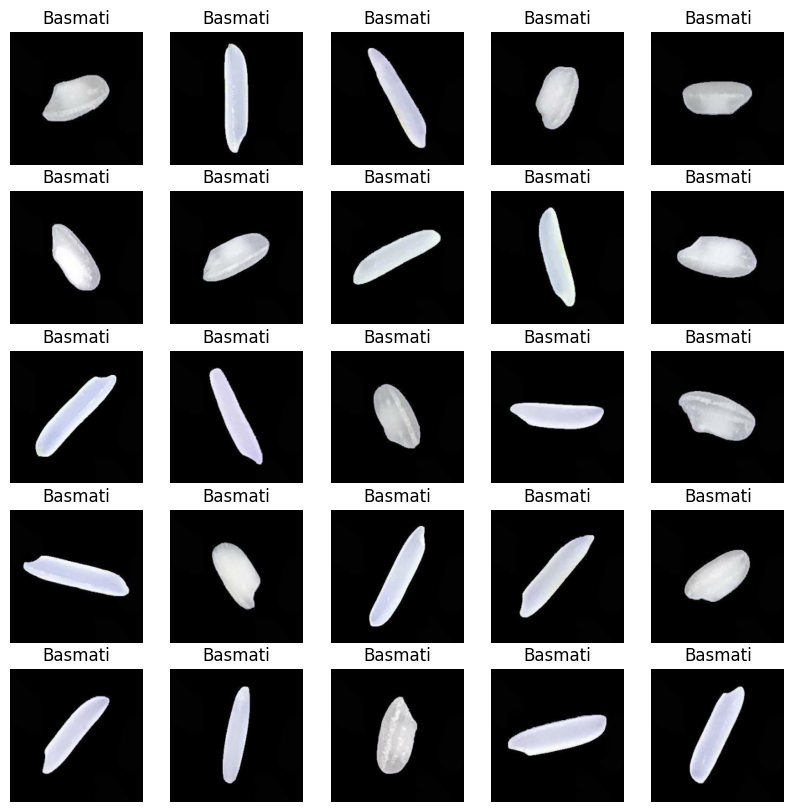

In [40]:
import matplotlib.pyplot as plt

class_names = ['Arborio','Basmati', 'Ipsala', 'Jasmine', 'Karacadag']



plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i].numpy())
    # class_idx = np.argmax(labels[i].numpy())
    plt.title(class_names[class_idx])
    
    plt.axis('off')

plt.show()


In [5]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')  # Arborio vs Basmati
])


C:\Users\Johnson\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)


Epoch 1/10


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 501ms/step - accuracy: 0.6938 - loss: 0.5626 - val_accuracy: 0.9667 - val_loss: 0.2034
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.9875 - loss: 0.0811 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 9.2815e-05
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 0.9937 - loss: 0.0062 - val_accuracy: 0.9833 - val_loss: 0.0446
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 430ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9833 - val_loss: 0.0299
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 428ms/step - accuracy: 1.0000 - loss: 2.4101e-05 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 428ms/step - accuracy: 0.9937 - loss: 0.0067 - val_accuracy: 0.9833 - val_loss: 0.0697
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 423ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 1.

In [18]:
model.save("rice_type_model.h5")


2/2 - 0s - 133ms/step - accuracy: 1.0000 - loss: 1.2740e-04


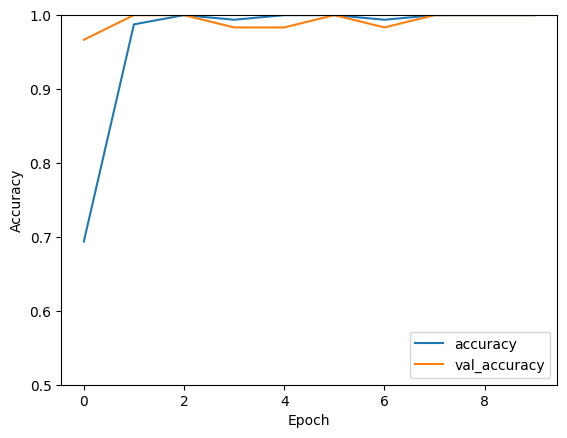

In [10]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_ds,verbose=2)

In [11]:
print(test_acc)

1.0
